# Phase 2: Multi-Model Evaluation & Cross-Member Comparison
**Coursework:** IT2011 Machine Learning Project  
**Author:** Group Evaluation Pipeline (All Members)  
**Scope:** Phase 2 Model Benchmark & Statistical Significance Testing  

This notebook performs the comprehensive, standardized evaluation and comparison of the models trained across all group members for Phase 2. It reads the serialized results and predictions generated via `src.evaluation.save_model_results()` and **trains no estimators**.

Before aggregating metrics, this notebook verifies strict comparability across all delivered model artifacts (identical split fingerprints, identical 5-fold partitions, unique review identifiers, and exact confusion matrix reconstruction). All visual and tabular outputs are saved to `results/phase2/comparison/`.

### 1. Environment Setup & Configuration
Configure project paths, load evaluation utilities, and define the expected Phase 2 modeling roster across group members.

In [1]:
import os
import sys
import json
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure repository root is in sys.path
repo_root = None
if "REPO_ROOT" in os.environ:
    repo_root = Path(os.environ["REPO_ROOT"]).resolve()
else:
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir] + list(current_dir.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_prep import find_repo_root
from src.evaluation import (
    load_model_results,
    validate_results,
    confusion_matrix,
    confusion_matrix_normalized,
    movie_confusion_tensor,
    make_bootstrap_indices,
    bootstrap_macro_f1,
    paired_bootstrap_difference,
    percentile_ci,
)

REPO_ROOT = find_repo_root()

# Helper to format paths relative to REPO_ROOT without exposing machine-specific absolute paths
def rel(p):
    try:
        return str(Path(p).resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return Path(p).name

# Allow overriding results directory via environment variable (used for testing)
RESULTS_DIR = Path(os.environ.get("PHASE2_RESULTS_DIR", REPO_ROOT / "results" / "phase2"))
COMPARISON_DIR = RESULTS_DIR / "comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# Expected Phase 2 models from group assignment roster
EXPECTED_MODELS = {
    "naive_bayes": ("Multinomial Naive Bayes", "IT25102549"),
    "logistic_regression": ("Logistic Regression", "IT25102550"),
    "linear_svc": ("Linear Support Vector Machine", "IT25102631"),
    "decision_tree": ("Decision Tree", "IT25102877"),
    "random_forest": ("Random Forest Classifier", "IT25102877"),
    "hist_gradient_boosting": ("Gradient Boosting", "IT25103066"),
    "mlp": ("Multi-Layer Perceptron (MLP)", "IT25103132"),
}

print(f"Repository Root        : {REPO_ROOT.name}")
print(f"Results Directory      : {rel(RESULTS_DIR)}")
print(f"Comparison Output Dir  : {rel(COMPARISON_DIR)}")
print(f"Expected Model Roster  : {len(EXPECTED_MODELS)} configurations registered")

Repository Root        : AI:ML Project
Results Directory      : results/phase2
Comparison Output Dir  : results/phase2/comparison
Expected Model Roster  : 7 configurations registered


### 2. Discover & Load Delivered Model Results
Scan `RESULTS_DIR` for all `*_results.json` files, validate schemas via `validate_results()`, and report delivery status across the expected model roster.

In [2]:
# Discover all results JSON files in RESULTS_DIR
discovered_files = sorted(glob.glob(str(RESULTS_DIR / "*_results.json")))
delivered_data = {}
unexpected_files = []

for filepath in discovered_files:
    p = Path(filepath)
    try:
        data = load_model_results(p)
        model_key = data.get("model_key")
        delivered_data[model_key] = {
            "data": data,
            "filepath": p,
        }
        if model_key not in EXPECTED_MODELS:
            unexpected_files.append(model_key)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")

# Build delivery status table
status_records = []
for model_key, (label, member_id) in EXPECTED_MODELS.items():
    is_delivered = model_key in delivered_data
    status_records.append({
        "Model Key": model_key,
        "Algorithm / Model": label,
        "Member ID": member_id,
        "Status": "delivered" if is_delivered else "not delivered yet",
    })

status_df = pd.DataFrame(status_records)
print("=== Phase 2 Model Delivery Status ===")
print(status_df.to_string(index=False))

if unexpected_files:
    print(f"\nNotice: Discovered {len(unexpected_files)} additional model file(s) not in expected roster: {unexpected_files}")

=== Phase 2 Model Delivery Status ===
             Model Key             Algorithm / Model  Member ID            Status
           naive_bayes       Multinomial Naive Bayes IT25102549 not delivered yet
   logistic_regression           Logistic Regression IT25102550 not delivered yet
            linear_svc Linear Support Vector Machine IT25102631 not delivered yet
         decision_tree                 Decision Tree IT25102877         delivered
         random_forest      Random Forest Classifier IT25102877         delivered
hist_gradient_boosting             Gradient Boosting IT25103066 not delivered yet
                   mlp  Multi-Layer Perceptron (MLP) IT25103132 not delivered yet


### 3. Comparability & Integrity Verification
Enforce strict experimental comparability checks across all delivered models before synthesizing metrics:
1. **Schema & Label Invariants:** Valid schema version and identical label ordering.
2. **Split Fingerprint:** Identical train/test row counts, test movie hash (`test_movies_sha256`), and test review hash (`test_review_ids_sha256`).
3. **Cross-Validation Invariants:** Identical 5-fold group partitions without leakage.
4. **Prediction Alignment:** Test predictions CSV must exist, `review_id` must be strictly unique, its exact sequence and ground-truth `y_true` must match the reference model, and the recomputed confusion matrix must match `test['confusion_matrix']`.
5. **Baselines:** Baseline benchmark scores must be identical across runs.

In [3]:
# Establish reference model for comparability checks (first delivered model)
split_keys = ["n_train", "n_test", "train_movies_sha256", "test_movies_sha256", "train_review_ids_sha256", "test_review_ids_sha256"]

ref_key = None
ref_data = None
ref_preds = None

# Identify reference model
for k, item in delivered_data.items():
    csv_path = RESULTS_DIR / f"{k}_test_predictions.csv"
    if csv_path.exists():
        ref_key = k
        ref_data = item["data"]
        ref_preds = pd.read_csv(csv_path)
        break

if ref_key is None:
    raise RuntimeError("No delivered model has an accompanying test predictions CSV.")

print(f"Reference Model for Comparability Checks: '{ref_key}'")

check_results = []
passed_models = {}
excluded_models = {}

for k, item in delivered_data.items():
    d = item["data"]
    reasons = []
    
    # 1. Schema version
    if d.get("schema_version") != ref_data.get("schema_version"):
        reasons.append(f"Schema version mismatch: {d.get('schema_version')} vs {ref_data.get('schema_version')}")
        
    # 2. Labels order
    if list(d.get("labels", [])) != list(ref_data.get("labels", [])):
        reasons.append("Labels order mismatch")
        
    # 3. Split fingerprint
    for sk in split_keys:
        val = d.get("split", {}).get(sk)
        ref_val = ref_data.get("split", {}).get(sk)
        if val != ref_val:
            reasons.append(f"Split fingerprint mismatch: {sk}")
            
    # 4. CV fingerprints
    if d.get("cv_fingerprints") != ref_data.get("cv_fingerprints"):
        reasons.append("CV fold fingerprints mismatch")
        
    # 5. Predictions CSV and alignment
    csv_path = RESULTS_DIR / f"{k}_test_predictions.csv"
    if not csv_path.exists():
        reasons.append("Missing test predictions CSV")
    else:
        p_df = pd.read_csv(csv_path)
        if p_df["review_id"].nunique() != len(p_df):
            reasons.append("Non-unique review_id in predictions")
        if list(p_df["review_id"]) != list(ref_preds["review_id"]):
            reasons.append("Predictions review_id sequence mismatch with reference")
        if list(p_df["y_true"]) != list(ref_preds["y_true"]):
            reasons.append("Predictions y_true sequence mismatch with reference")
        cm_recomp = confusion_matrix(p_df["y_true"], p_df["y_pred"], labels=d["labels"]).tolist()
        if cm_recomp != d["test"]["confusion_matrix"]:
            reasons.append("Recomputed confusion matrix does not match JSON confusion_matrix")
            
    # 6. Baselines
    if d.get("baselines") != ref_data.get("baselines"):
        reasons.append("Baseline benchmarks mismatch")
        
    # Check library versions (reported, does not fail)
    version_diffs = []
    for pkg, ver in d.get("created_with", {}).items():
        ref_ver = ref_data.get("created_with", {}).get(pkg)
        if ref_ver and ver != ref_ver:
            version_diffs.append(f"{pkg}:{ver} vs {ref_ver}")
            
    status = "PASS" if not reasons else "FAIL"
    reason_str = "; ".join(reasons) if reasons else "All comparability checks passed"
    
    check_results.append({
        "Model Key": k,
        "Status": status,
        "Issues / Failure Reason": reason_str,
        "Library Version Differences": ", ".join(version_diffs) if version_diffs else "None (Exact Match)",
    })
    
    if status == "PASS":
        passed_models[k] = {
            "data": d,
            "preds": p_df,
        }
    else:
        excluded_models[k] = reason_str

comparability_df = pd.DataFrame(check_results)
print("\n=== Comparability Verification Summary ===")
print(comparability_df[["Model Key", "Status", "Issues / Failure Reason"]].to_string(index=False))

print(f"\n✔ Passed Models ({len(passed_models)}): {list(passed_models.keys())}")
if excluded_models:
    print(f"⚠ Excluded Models ({len(excluded_models)}): {excluded_models}")

Reference Model for Comparability Checks: 'decision_tree'

=== Comparability Verification Summary ===
    Model Key Status         Issues / Failure Reason
decision_tree   PASS All comparability checks passed
random_forest   PASS All comparability checks passed

✔ Passed Models (2): ['decision_tree', 'random_forest']


### 4. Consolidated Model Comparison Table
Synthesize performance metrics across all verified models, sorted by held-out test Macro-F1 descending. Multi-class chance baselines (majority class, stratified random, and uniform random) are included as explicit benchmark references.

In [4]:
# Compute test macro-F1 95% bootstrap confidence intervals for each passed model
n_movies = ref_preds["movie_name"].nunique()
shared_boot_idx = make_bootstrap_indices(n_movies=n_movies, n_boot=2000, seed=42)

boot_cis = {}
movie_tensors = {}

for k, pitem in passed_models.items():
    _, tensor = movie_confusion_tensor(pitem["preds"])
    movie_tensors[k] = tensor
    draws = bootstrap_macro_f1(tensor, shared_boot_idx)
    boot_cis[k] = percentile_ci(draws, level=0.95)

table_rows = []
for k, pitem in passed_models.items():
    d = pitem["data"]
    meta = d["meta"]
    tuning = meta["tuning"]
    scoring_val = tuning.get("scoring", [])
    scoring_str = ", ".join(scoring_val) if isinstance(scoring_val, list) else str(scoring_val)
    
    cv = d["cv"]
    test = d["test"]
    ci = boot_cis[k]
    
    table_rows.append({
        "Model": meta.get("model_label", k),
        "Member ID": meta.get("member_id", "-"),
        "Algorithm": meta.get("algorithm", "-"),
        "Preprocessing": meta.get("preprocessing", "-"),
        "Tuning Budget": f"{tuning.get('method', '-')} ({tuning.get('n_configs', '-')} configs x {tuning.get('n_folds', '-')} folds, {scoring_str})",
        "CV Macro-F1 (Mean ± Std)": f"{cv['macro_f1']['mean']:.4f} ± {cv['macro_f1']['std']:.4f}",
        "CV Accuracy": f"{cv['accuracy']['mean']:.4f}",
        "Test Accuracy": f"{test['accuracy']:.4f}",
        "Test Macro-F1 (95% CI)": f"{test['macro_f1']:.4f} [{ci[0]:.4f}, {ci[1]:.4f}]",
        "Test Weighted-F1": f"{test['weighted_f1']:.4f}",
        "_raw_test_macro_f1": test["macro_f1"],
    })

# Sort passed models by test macro-F1 descending
main_df = pd.DataFrame(table_rows).sort_values(by="_raw_test_macro_f1", ascending=False).drop(columns=["_raw_test_macro_f1"])

# Append benchmark baseline reference rows
base = ref_data["baselines"]
baseline_rows = [
    {
        "Model": "Majority Class Predictor",
        "Member ID": "-",
        "Algorithm": "DummyClassifier (most_frequent)",
        "Preprocessing": "-",
        "Tuning Budget": "-",
        "CV Macro-F1 (Mean ± Std)": "-",
        "CV Accuracy": "-",
        "Test Accuracy": f"{base['majority']['accuracy']:.4f}",
        "Test Macro-F1 (95% CI)": f"{base['majority']['macro_f1']:.4f}",
        "Test Weighted-F1": f"{base['majority']['weighted_f1']:.4f}",
    },
    {
        "Model": "Stratified Random Baseline",
        "Member ID": "-",
        "Algorithm": "DummyClassifier (stratified, 200 seeds)",
        "Preprocessing": "-",
        "Tuning Budget": "-",
        "CV Macro-F1 (Mean ± Std)": "-",
        "CV Accuracy": "-",
        "Test Accuracy": f"{base['stratified_random']['accuracy_mean']:.4f} ± {base['stratified_random']['accuracy_std']:.4f}",
        "Test Macro-F1 (95% CI)": f"{base['stratified_random']['macro_f1_mean']:.4f} ± {base['stratified_random']['macro_f1_std']:.4f}",
        "Test Weighted-F1": "-",
    },
    {
        "Model": "Uniform Random Baseline",
        "Member ID": "-",
        "Algorithm": "DummyClassifier (uniform, 200 seeds)",
        "Preprocessing": "-",
        "Tuning Budget": "-",
        "CV Macro-F1 (Mean ± Std)": "-",
        "CV Accuracy": "-",
        "Test Accuracy": f"{base['uniform_random']['accuracy_mean']:.4f} ± {base['uniform_random']['accuracy_std']:.4f}",
        "Test Macro-F1 (95% CI)": f"{base['uniform_random']['macro_f1_mean']:.4f} ± {base['uniform_random']['macro_f1_std']:.4f}",
        "Test Weighted-F1": "-",
    },
]

full_comparison_df = pd.concat([main_df, pd.DataFrame(baseline_rows)], ignore_index=True)

# Export comparison table to CSV and Markdown
csv_out = COMPARISON_DIR / "model_comparison_table.csv"
md_out = COMPARISON_DIR / "model_comparison_table.md"

full_comparison_df.to_csv(csv_out, index=False)

def _df_to_markdown(df):
    headers = list(df.columns)
    rows = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for _, r in df.iterrows():
        rows.append("| " + " | ".join(str(val) for val in r) + " |")
    return "\n".join(rows)

with open(md_out, "w", encoding="utf-8") as f:
    f.write(_df_to_markdown(full_comparison_df))

print("=== Phase 2 Consolidated Model Comparison Table ===")
print(full_comparison_df.to_string(index=False))
print(f"\n✔ Table saved to: {rel(csv_out)} and {rel(md_out)}")

=== Phase 2 Consolidated Model Comparison Table ===
                     Model  Member ID                               Algorithm                                                      Preprocessing                                                              Tuning Budget CV Macro-F1 (Mean ± Std) CV Accuracy   Test Accuracy  Test Macro-F1 (95% CI) Test Weighted-F1
             Random Forest IT25102877                  RandomForestClassifier TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1) RandomizedSearchCV (15 configs x 5 folds, macro_f1, accuracy, weighted_f1)          0.1708 ± 0.0138      0.2594          0.2729 0.1942 [0.1543, 0.2310]           0.2707
             Decision Tree IT25102877                  DecisionTreeClassifier TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1)       GridSearchCV (30 configs x 5 folds, macro_f1, accuracy, weighted_f1)          0.1767 ± 0.0211      0.2862          0.2866 0.1914 [0.1459, 0.2346]           0.2788
  Majo

### 5. Pairwise Statistical Significance Testing (Movie Bootstrap)
Evaluate whether observed differences on the held-out test set exceed test-set sampling variability. Reviews from the same movie share stylistic, thematic, and directorial characteristics, so bootstrap resampling is performed at the **movie cluster level** ($B=2,000$ cluster bootstrap draws with seed 42).

> **Important Methodological Note:** The cluster bootstrap isolates test-set sampling variation across movies. It does not measure variability originating from randomized training procedures (e.g., neural initialization) or cross-environment library differences.

In [5]:
if len(passed_models) < 2:
    print("Fewer than 2 models passed comparability checks; skipping pairwise bootstrap significance testing.")
else:
    # Identify top model by held-out test macro-F1
    best_key = max(passed_models.keys(), key=lambda k: passed_models[k]["data"]["test"]["macro_f1"])
    best_label = passed_models[best_key]["data"]["meta"].get("model_label", best_key)
    best_score = passed_models[best_key]["data"]["test"]["macro_f1"]
    best_tensor = movie_tensors[best_key]
    
    diff_records = []
    tied_models = []
    
    for k, pitem in passed_models.items():
        if k == best_key:
            continue
        label = pitem["data"]["meta"].get("model_label", k)
        score = pitem["data"]["test"]["macro_f1"]
        diff_draws = paired_bootstrap_difference(best_tensor, movie_tensors[k], shared_boot_idx)
        ci_diff = percentile_ci(diff_draws, level=0.95)
        mean_diff = float(np.mean(diff_draws))
        is_tied = ci_diff[0] <= 0 <= ci_diff[1]
        
        if is_tied:
            tied_models.append(label)
            
        diff_records.append({
            "Comparison": f"{best_label} vs. {label}",
            "Score Difference": f"{mean_diff:+.4f}",
            "95% CI of Difference": f"[{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]",
            "Statistically Tied with Best?": "Yes (CI includes 0)" if is_tied else "No (Significant Difference)",
        })
        
    diff_df = pd.DataFrame(diff_records)
    print(f"=== Pairwise Difference Against Top Model ({best_label}) ===")
    print(diff_df.to_string(index=False))
    
    # Computed summary statement
    if len(tied_models) == len(passed_models) - 1:
        summary_sentence = (
            f"The top-performing model on the held-out test set is {best_label} (Macro-F1: {best_score:.4f}), "
            f"but all evaluated models ({', '.join(tied_models)}) are statistically tied with the best model "
            f"because every 95% bootstrap difference interval spans zero, so no model is clearly different."
        )
    elif tied_models:
        summary_sentence = (
            f"The top-performing model on the held-out test set is {best_label} (Macro-F1: {best_score:.4f}). "
            f"Statistically tied models: {', '.join(tied_models)}. All other models exhibit statistically significant lower performance."
        )
    else:
        summary_sentence = (
            f"The top-performing model on the held-out test set is {best_label} (Macro-F1: {best_score:.4f}), "
            f"which significantly outperforms all competing models at the 95% confidence level."
        )
        
    print(f"\n{summary_sentence}")

=== Pairwise Difference Against Top Model (Random Forest) ===
                     Comparison Score Difference 95% CI of Difference Statistically Tied with Best?
Random Forest vs. Decision Tree          +0.0028    [-0.0456, 0.0511]           Yes (CI includes 0)

The top-performing model on the held-out test set is Random Forest (Macro-F1: 0.1942), but all evaluated models (Decision Tree) are statistically tied with the best model because every 95% bootstrap difference interval spans zero, so no model is clearly different.


### 6. Cross-Validation vs. Held-Out Test Generalization Rankings
Compare the relative ranking of models on internal grouped cross-validation against their performance on the held-out test set to detect ranking inversions.

In [6]:
# Extract rankings
cv_rank_order = sorted(passed_models.keys(), key=lambda k: passed_models[k]["data"]["cv"]["macro_f1"]["mean"], reverse=True)
test_rank_order = sorted(passed_models.keys(), key=lambda k: passed_models[k]["data"]["test"]["macro_f1"], reverse=True)

ranking_records = []
disagreements = []

for rank_idx in range(len(passed_models)):
    cv_k = cv_rank_order[rank_idx]
    test_k = test_rank_order[rank_idx]
    cv_lbl = passed_models[cv_k]["data"]["meta"].get("model_label", cv_k)
    test_lbl = passed_models[test_k]["data"]["meta"].get("model_label", test_k)
    cv_score = passed_models[cv_k]["data"]["cv"]["macro_f1"]["mean"]
    test_score = passed_models[test_k]["data"]["test"]["macro_f1"]
    
    ranking_records.append({
        "Rank": f"#{rank_idx + 1}",
        "CV Macro-F1 Rank": f"{cv_lbl} ({cv_score:.4f})",
        "Test Macro-F1 Rank": f"{test_lbl} ({test_score:.4f})",
        "Rank Match": "Match" if cv_k == test_k else "Disagreement",
    })
    
    if cv_k != test_k:
        disagreements.append(f"Rank #{rank_idx + 1}: CV prefers {cv_lbl} but Test prefers {test_lbl}")

ranking_df = pd.DataFrame(ranking_records)
print("=== Model Generalization Ranking Comparison ===")
print(ranking_df.to_string(index=False))

if disagreements:
    print(f"\n⚠ Ranking Disagreement Detected: {'; '.join(disagreements)}.")
else:
    print("\n✔ Complete agreement: Cross-validation ranking matches held-out test set ranking exactly.")

=== Model Generalization Ranking Comparison ===
Rank       CV Macro-F1 Rank     Test Macro-F1 Rank   Rank Match
  #1 Decision Tree (0.1767) Random Forest (0.1942) Disagreement
  #2 Random Forest (0.1708) Decision Tree (0.1914) Disagreement

⚠ Ranking Disagreement Detected: Rank #1: CV prefers Decision Tree but Test prefers Random Forest; Rank #2: CV prefers Random Forest but Test prefers Decision Tree.


### 7. Comparative Visualizations
Generate standardized comparative diagnostic figures saved directly to `results/phase2/comparison/`:
- **Figure 7a:** Grouped bar chart comparing CV Macro-F1 (± std) against Test Macro-F1 (± bootstrap CI) alongside the stratified random baseline.
- **Figure 7b:** Heatmap of per-class F1 scores across models and emotion classes.
- **Figure 7c:** Normalized confusion matrices for each passed model.
- **Figure 7d:** Box and strip plot of cross-validation fold stability.

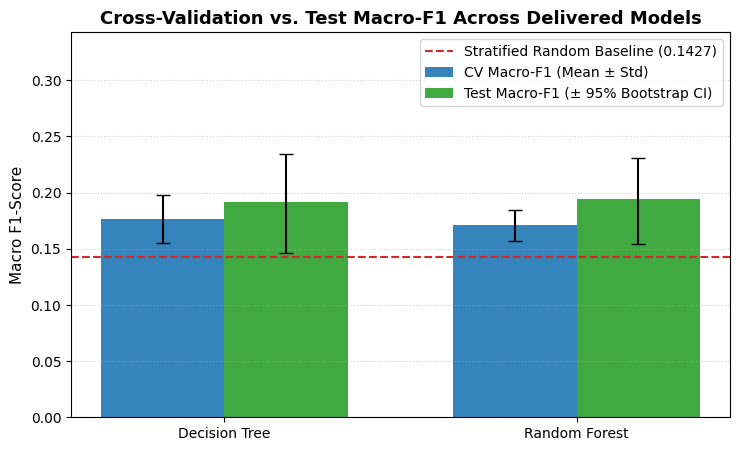

✔ Figure 7a saved to: results/phase2/comparison/comparison_macro_f1.png


In [7]:
# Figure 7a: Grouped Bar Chart of CV vs. Test Macro-F1
fig, ax = plt.subplots(figsize=(8.5, 5))

model_keys = list(passed_models.keys())
model_labels = [passed_models[k]["data"]["meta"].get("model_label", k) for k in model_keys]
n_mod = len(model_keys)
x = np.arange(n_mod)
width = 0.35

cv_means = [passed_models[k]["data"]["cv"]["macro_f1"]["mean"] for k in model_keys]
cv_stds = [passed_models[k]["data"]["cv"]["macro_f1"]["std"] for k in model_keys]
test_scores = [passed_models[k]["data"]["test"]["macro_f1"] for k in model_keys]

test_err_low = [test_scores[i] - boot_cis[k][0] for i, k in enumerate(model_keys)]
test_err_high = [boot_cis[k][1] - test_scores[i] for i, k in enumerate(model_keys)]

ax.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=5, label="CV Macro-F1 (Mean ± Std)", color="#1f77b4", alpha=0.9)
ax.bar(x + width/2, test_scores, width, yerr=[test_err_low, test_err_high], capsize=5, label="Test Macro-F1 (± 95% Bootstrap CI)", color="#2ca02c", alpha=0.9)

strat_ref = ref_data["baselines"]["stratified_random"]["macro_f1_mean"]
ax.axhline(strat_ref, color="#d62728", linestyle="--", linewidth=1.5, label=f"Stratified Random Baseline ({strat_ref:.4f})")

ax.set_title("Cross-Validation vs. Test Macro-F1 Across Delivered Models", fontsize=13, fontweight="bold")
ax.set_ylabel("Macro F1-Score", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylim(0, max(max(cv_means) + max(cv_stds), max(test_scores) + 0.08) * 1.25)
ax.grid(True, linestyle=":", alpha=0.6, axis="y")
ax.legend(loc="upper right", frameon=True)

fig_path_a = COMPARISON_DIR / "comparison_macro_f1.png"
fig.savefig(fig_path_a, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7a saved to: {rel(fig_path_a)}")

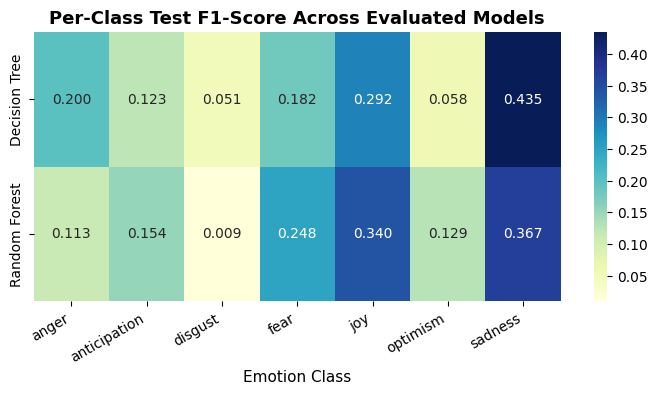

✔ Figure 7b saved to: results/phase2/comparison/comparison_per_class_f1.png


In [8]:
# Figure 7b: Per-Class F1-Score Heatmap
labels = ref_data["labels"]
heatmap_data = []
row_labels = []

for k in model_keys:
    d = passed_models[k]["data"]
    row_labels.append(d["meta"].get("model_label", k))
    heatmap_data.append([d["test"]["per_class"][lbl]["f1"] for lbl in labels])

fig, ax = plt.subplots(figsize=(8.5, max(3.5, len(model_keys) * 1.5)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=row_labels,
    cbar=True,
    ax=ax,
)
ax.set_title("Per-Class Test F1-Score Across Evaluated Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Emotion Class", fontsize=11)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)

fig_path_b = COMPARISON_DIR / "comparison_per_class_f1.png"
fig.savefig(fig_path_b, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7b saved to: {rel(fig_path_b)}")

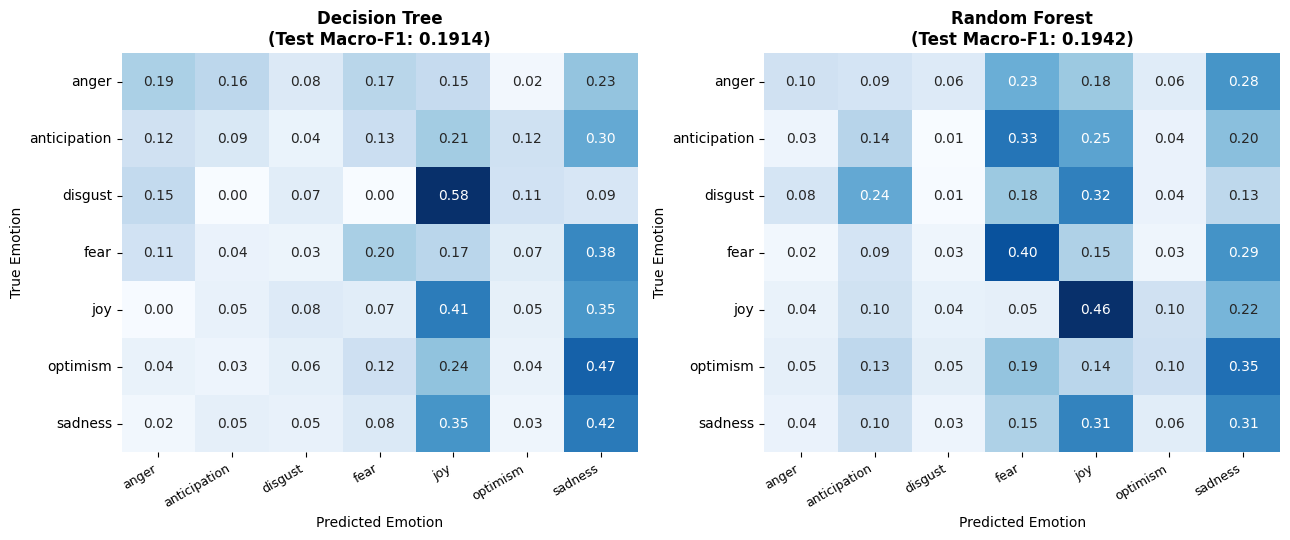

✔ Figure 7c saved to: results/phase2/comparison/comparison_confusion_matrices.png


In [9]:
# Figure 7c: Grid of Row-Normalized Test Confusion Matrices
n_mod = len(model_keys)
fig, axes = plt.subplots(1, n_mod, figsize=(6.5 * n_mod, 5.5), squeeze=False)

for i, k in enumerate(model_keys):
    ax = axes[0, i]
    d = passed_models[k]["data"]
    lbl = d["meta"].get("model_label", k)
    cm_norm = confusion_matrix_normalized(d["test"]["confusion_matrix"])
    
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{lbl}\n(Test Macro-F1: {d['test']['macro_f1']:.4f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Emotion", fontsize=10)
    ax.set_ylabel("True Emotion", fontsize=10)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)

plt.tight_layout()
fig_path_c = COMPARISON_DIR / "comparison_confusion_matrices.png"
fig.savefig(fig_path_c, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7c saved to: {rel(fig_path_c)}")

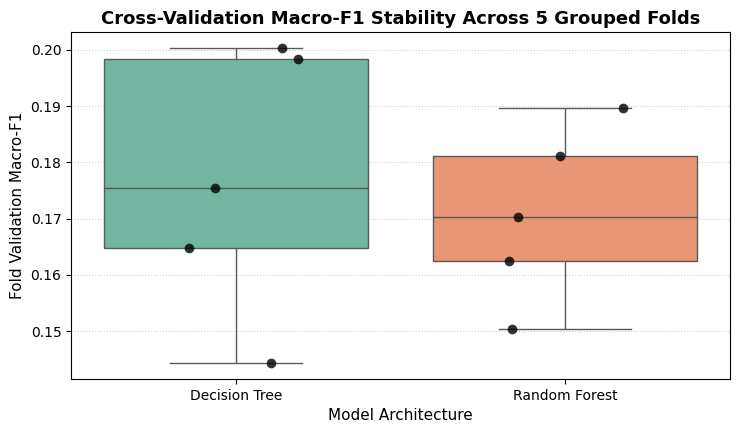

✔ Figure 7d saved to: results/phase2/comparison/comparison_cv_folds.png


In [10]:
# Figure 7d: Cross-Validation Fold Stability Box & Strip Plot
fold_records = []
for k in model_keys:
    d = passed_models[k]["data"]
    lbl = d["meta"].get("model_label", k)
    for fold_num, score in enumerate(d["cv"]["macro_f1"]["folds"], start=1):
        fold_records.append({
            "Model": lbl,
            "Fold": fold_num,
            "Macro-F1": score,
        })

df_folds = pd.DataFrame(fold_records)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.boxplot(
    x="Model",
    y="Macro-F1",
    hue="Model",
    data=df_folds,
    ax=ax,
    palette="Set2",
    legend=False,
)
sns.stripplot(
    x="Model",
    y="Macro-F1",
    data=df_folds,
    ax=ax,
    color="black",
    size=7,
    jitter=0.2,
    alpha=0.8,
)

ax.set_title("Cross-Validation Macro-F1 Stability Across 5 Grouped Folds", fontsize=13, fontweight="bold")
ax.set_xlabel("Model Architecture", fontsize=11)
ax.set_ylabel("Fold Validation Macro-F1", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6, axis="y")

fig_path_d = COMPARISON_DIR / "comparison_cv_folds.png"
fig.savefig(fig_path_d, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7d saved to: {rel(fig_path_d)}")

### 8. Emotion Class Difficulty & Breakdown
Identify which emotions are systematically easiest and hardest to predict across all model architectures, and inspect the per-class precision, recall, and support of the top-performing model.

In [11]:
# Compute mean F1 per emotion class across all passed models
class_mean_f1 = {}
for lbl in labels:
    class_mean_f1[lbl] = float(np.mean([passed_models[k]["data"]["test"]["per_class"][lbl]["f1"] for k in model_keys]))

sorted_classes = sorted(class_mean_f1.items(), key=lambda x: x[1])
hardest_class, hardest_score = sorted_classes[0]
easiest_class, easiest_score = sorted_classes[-1]

print("=== Emotion Class Difficulty Across Models ===")
print(f"• Easiest Emotion (Highest Mean F1) : '{easiest_class}' (Mean F1: {easiest_score:.4f})")
print(f"• Hardest Emotion (Lowest Mean F1)  : '{hardest_class}' (Mean F1: {hardest_score:.4f})\n")

class_summary_df = pd.DataFrame([
    {"Emotion": lbl, "Mean Test F1 Across Models": f"{class_mean_f1[lbl]:.4f}"}
    for lbl in [sc[0] for sc in sorted_classes[::-1]]
])
print(class_summary_df.to_string(index=False))

# Best model per-class metrics table
best_key = max(passed_models.keys(), key=lambda k: passed_models[k]["data"]["test"]["macro_f1"])
best_d = passed_models[best_key]["data"]
best_lbl = best_d["meta"].get("model_label", best_key)

best_per_class = pd.DataFrame(best_d["test"]["per_class"]).T[["precision", "recall", "f1", "support"]]
best_per_class.columns = ["Precision", "Recall", "F1-Score", "Support"]
best_per_class["Support"] = best_per_class["Support"].astype(int)

print(f"\n=== Top Model ({best_lbl}) Detailed Per-Class Breakdown ===")
print(best_per_class.round(4).to_string())

=== Emotion Class Difficulty Across Models ===
• Easiest Emotion (Highest Mean F1) : 'sadness' (Mean F1: 0.4009)
• Hardest Emotion (Lowest Mean F1)  : 'disgust' (Mean F1: 0.0301)

     Emotion Mean Test F1 Across Models
     sadness                     0.4009
         joy                     0.3161
        fear                     0.2148
       anger                     0.1562
anticipation                     0.1382
    optimism                     0.0932
     disgust                     0.0301

=== Top Model (Random Forest) Detailed Per-Class Breakdown ===
              Precision  Recall  F1-Score  Support
anger            0.1333  0.0973    0.1125      185
anticipation     0.1690  0.1409    0.1537      433
disgust          0.0093  0.0093    0.0093      107
fear             0.1803  0.3971    0.2480      277
joy              0.2716  0.4557    0.3403      553
optimism         0.1765  0.1014    0.1288      355
sadness          0.4583  0.3059    0.3669     1311


### 9. Fairness Caveats & Methodological Context
Synthesize preprocessing configurations, hyperparameter optimization budgets, and execution environments to contextualize performance differences.

In [12]:
caveat_records = []
for k in model_keys:
    d = passed_models[k]["data"]
    meta = d["meta"]
    tuning = meta["tuning"]
    cw = d.get("created_with", {})
    caveat_records.append({
        "Model": meta.get("model_label", k),
        "Preprocessing Pipeline": meta.get("preprocessing", "-"),
        "Tuning Method": tuning.get("method", "-"),
        "Tuning Budget": f"{tuning.get('n_configs', '-')} configs x {tuning.get('n_folds', '-')} folds",
        "Elapsed Time (s)": f"{tuning.get('elapsed_seconds', 0.0):.1f}s",
        "Python": cw.get("python", "-"),
        "scikit-learn": cw.get("sklearn", "-"),
    })

caveat_df = pd.DataFrame(caveat_records)
print("=== Experimental Budget & Environment Context ===")
print(caveat_df.to_string(index=False))

=== Experimental Budget & Environment Context ===
        Model                                             Preprocessing Pipeline      Tuning Method        Tuning Budget Elapsed Time (s) Python scikit-learn
Decision Tree TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1)       GridSearchCV 30 configs x 5 folds           627.0s 3.14.3        1.9.0
Random Forest TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1) RandomizedSearchCV 15 configs x 5 folds           338.4s 3.14.3        1.9.0


#### Methodological Considerations for Group Synthesis:
1. **Hyperparameter Tuning Budgets:** Competing models were evaluated under varying computational search budgets (e.g., exhaustive grid search vs. randomized sampling) reflecting architectural execution costs.
2. **Cluster Grouping & Single Split:** The held-out test set comprises 3,221 reviews across exactly 261 movies. While cluster-level grouping prevents information leakage, all comparisons reflect this specific held-out test split.
3. **Library Version Sensitivity:** Individual decision tree splits and numerical ties in greedy impurity reduction can exhibit slight variation across scikit-learn versions, even with fixed random seeds.

### 10. Summary Serialization
Export structured summary metadata to `results/phase2/comparison/comparison_summary.json` for automated consumption and reporting.

In [13]:
summary_payload = {
    "reference_model": ref_key,
    "models_evaluated_count": len(delivered_data),
    "models_passed_count": len(passed_models),
    "models_included": list(passed_models.keys()),
    "models_excluded": excluded_models,
    "best_model": {
        "model_key": best_key,
        "model_label": best_lbl,
        "test_macro_f1": float(best_d["test"]["macro_f1"]),
        "test_accuracy": float(best_d["test"]["accuracy"]),
    },
    "statistically_tied_with_best": tied_models if len(passed_models) >= 2 else [],
    "rankings": {
        "cv_macro_f1_ranking": [passed_models[k]["data"]["meta"].get("model_label", k) for k in cv_rank_order],
        "test_macro_f1_ranking": [passed_models[k]["data"]["meta"].get("model_label", k) for k in test_rank_order],
    },
    "generated_artifacts": {
        "comparison_table_csv": rel(csv_out),
        "comparison_table_md": rel(md_out),
        "figure_macro_f1": rel(fig_path_a),
        "figure_per_class_f1": rel(fig_path_b),
        "figure_confusion_matrices": rel(fig_path_c),
        "figure_cv_folds": rel(fig_path_d),
    },
}

summary_json_path = COMPARISON_DIR / "comparison_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("=== Comparison Summary Exported ===")
print(f"• Summary JSON: {rel(summary_json_path)}")
print(json.dumps(summary_payload, indent=2))

=== Comparison Summary Exported ===
• Summary JSON: results/phase2/comparison/comparison_summary.json
{
  "reference_model": "decision_tree",
  "models_evaluated_count": 2,
  "models_passed_count": 2,
  "models_included": [
    "decision_tree",
    "random_forest"
  ],
  "models_excluded": {},
  "best_model": {
    "model_key": "random_forest",
    "model_label": "Random Forest",
    "test_macro_f1": 0.19421056492629904,
    "test_accuracy": 0.2728966159577771
  },
  "statistically_tied_with_best": [
    "Decision Tree"
  ],
  "rankings": {
    "cv_macro_f1_ranking": [
      "Decision Tree",
      "Random Forest"
    ],
    "test_macro_f1_ranking": [
      "Random Forest",
      "Decision Tree"
    ]
  },
  "generated_artifacts": {
    "comparison_table_csv": "results/phase2/comparison/model_comparison_table.csv",
    "comparison_table_md": "results/phase2/comparison/model_comparison_table.md",
    "figure_macro_f1": "results/phase2/comparison/comparison_macro_f1.png",
    "figure_per_